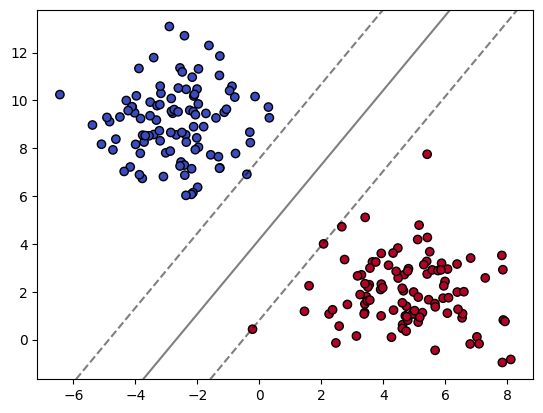

KNN : 0.9666666666666667
SVM  : 0.7333333333333333

KNN  Matrix:
 [[ 9  0  0]
 [ 0 12  1]
 [ 0  0  8]]

SVM  Matrix:
 [[ 9  0  0]
 [ 0 13  0]
 [ 0  8  0]]


In [100]:
import numpy as np
from collections import Counter
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
#KNN

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X_train, y_train):
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)

    def predict(self, X_test):
        X_test = np.array(X_test)
        preds = []
        for x in X_test:
            distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
            k_indices = np.argsort(distances)[: self.k]
            k_nearest_labels = self.y_train[k_indices]
            most_common = Counter(k_nearest_labels).most_common(1)[0][0]
            preds.append(most_common)
        return np.array(preds)



iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)



#SVM

class SVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters

    def fit(self, X, y):
        y = np.where(y == 0, -1, 1)

        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - y[idx] * x_i)
                    self.b -= self.lr * y[idx]

    def predict(self, X):
        linear_output = np.dot(X, self.w) - self.b
        return np.where(linear_output >= 0, 1, 0)


X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42
)


import matplotlib.pyplot as plt

def plot_svm_boundary(X, y, model):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

   
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = (np.dot(xy, model.w) - model.b).reshape(XX.shape)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
  
    plt.show()


svm_synthetic = SVM()
svm_synthetic.fit(X2_train, y2_train)

plot_svm_boundary(X2, y2, svm_synthetic)
knn = KNN(k=5)
knn.fit(X_train, y_train)

svm = SVM()
svm.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
svm_pred = svm.predict(X_test)

print("KNN :", accuracy_score(y_test, knn_pred))
print("SVM  :", accuracy_score(y_test, svm_pred))

print("\nKNN  Matrix:\n", confusion_matrix(y_test, knn_pred))
print("\nSVM  Matrix:\n", confusion_matrix(y_test, svm_pred))